In [37]:
# import Pkg
# Pkg.add("PythonCall")
# Pkg.add("CondaPkg")
# ENV["JULIA_PYTHONEXE"] = "C:\\Users\\micha\\AppData\\Local\\Programs\\Python\\Python312\\python.exe" # ścieżka do pythona
# Pkg.build("PythonCall")

In [53]:
ENV["DATADEPS_ALWAYS_ACCEPT"] = "true" 

using MLDatasets
using Flux
using Flux: logitcrossentropy, onehotbatch
using Statistics
using Random
using LinearAlgebra
using PythonCall
using CondaPkg

BLAS.set_num_threads(1)
include("clothesolver.jl")

train_data = MLDatasets.FashionMNIST(split=:train)
test_data  = MLDatasets.FashionMNIST(split=:test)

X_train = Float32.(reshape(train_data.features, 28, 28, 1, :))
X_test  = Float32.(reshape(test_data.features, 28, 28, 1, :))

Y_train_raw = train_data.targets
Y_test_raw  = test_data.targets

Y_train = Float32.(onehotbatch(Y_train_raw, 0:9))
Y_test  = Float32.(onehotbatch(Y_test_raw, 0:9))

println("Wymiary: ", size(X_train))

Wymiary: (28, 28, 1, 60000)


In [55]:
my_net_def = Chain(
  Conv((3, 3), 1 => 6,  bias=false),
  MaxPool((2, 2)),
  Conv((3, 3), 6 => 16, bias=false),
  MaxPool((2, 2)),
  Flatten(),
  Dense(400 => 84, relu),
  Dropout(0.4),
  Dense(84 => 10)
)

println("Alokacja wstępna (batch_size = $(my_model.batch_size)):")
@time my_model = build_model(my_net_def, (28, 28, 1); batch_size=10)
println()

function test(model::CompiledModel, X, Y_raw)
    correct     = 0
    N           = size(X, 4)
    bs          = model.batch_size
    input_node  = model.input
    final_layer = model.chain.layers[end]

    x_flat = parent(input_node.data)
    len_x  = 28 * 28 * 1

    for i in 1:bs:N
        b_end    = min(i + bs - 1, N)
        actual_b = b_end - i + 1

        fill!(input_node.data, 0f0)
        
        off_X = (i - 1) * len_x
        elements_to_copy = actual_b * len_x
        @inbounds @simd for k in 1:elements_to_copy
            x_flat[k] = X[off_X + k]
        end

        forward!(model.chain, input_node, false)

        for b in 1:actual_b
            pred_class = argmax(@view(final_layer.out.data[:, b])) - 1
            correct += (pred_class == Y_raw[i + b - 1])
        end
    end

    acc = round(correct / N * 100, digits=2)
    return acc
end

function train!(model::CompiledModel, X, Y; η::Float32)
    bs          = model.batch_size
    input_node  = model.input
    target_node = model.target
    loss_fn     = model.loss
    N           = size(X, 4)
    indices     = randperm(N)
    total_loss  = 0.0
    n_batches   = 0

    x_flat = parent(input_node.data)
    y_flat = parent(target_node.data)
    len_x  = 784 # image size 28 x 28 x 1
    len_y  = 10

    for b_start in 1:bs:N
        b_end     = min(b_start + bs - 1, N)
        b_end - b_start + 1 < bs && break
        
        batch_idx = @view indices[b_start:b_end]

        zero_w_grad!(model.pool)
        zero_a_grad!(model.pool)

        for (i, idx) in enumerate(batch_idx)
            off_in = (i - 1) * len_x
            off_X  = (idx - 1) * len_x
            @inbounds @simd for k in 1:len_x
                x_flat[off_in + k] = X[off_X + k]
            end
            
            off_tgt = (i - 1) * len_y
            off_Y   = (idx - 1) * len_y
            @inbounds @simd for k in 1:len_y
                y_flat[off_tgt + k] = Y[off_Y + k]
            end
        end

        preds      = forward!(model.chain, input_node, true)
        batch_loss = primal!(loss_fn, preds, target_node)

        loss_fn.out.grad[1] = 1.0f0
        adjoint!(loss_fn, preds, target_node)
        backward!(model.chain, input_node, true)

        optimize!(model.pool, η)
        total_loss += batch_loss
        n_batches  += 1
    end
    return total_loss / n_batches
end

println("[x] Model przed treningiem:")
println("Acc: ", test(my_model, X_test, Y_test_raw), "%")

println("\n[x] Trenowanie...")
@time for ep in 1:3
    L   = train!(my_model, X_train, Y_train; η=0.02f0)
    acc = test(my_model, X_test, Y_test_raw)
    println("[+] Epoka $ep | Loss: $(round(L, digits=4)) | Acc: $acc%")
end

Alokacja wstępna (batch_size = 10):
  0.108583 seconds (700 allocations: 5.970 MiB, 98.66% gc time)

[x] Model przed treningiem:
Acc: 13.36%

[x] Trenowanie...
[+] Epoka 1 | Loss: 0.565 | Acc: 85.57%
[+] Epoka 2 | Loss: 0.408 | Acc: 86.65%
[+] Epoka 3 | Loss: 0.3644 | Acc: 88.36%
 19.383079 seconds (106.44 k allocations: 6.709 MiB, 0.97% compilation time)


In [57]:
flux_net = Flux.Chain(
  Flux.Conv((3, 3), 1 => 6, pad=1, bias=false),
  Flux.MaxPool((2, 2)),
  Flux.Conv((3, 3), 6 => 16, pad=1, bias=false),
  Flux.MaxPool((2, 2)),
  Flux.flatten,
  Flux.Dense(784 => 84, Flux.relu),
  Flux.Dropout(0.4),
  Flux.Dense(84 => 10)
)
opt_state = Flux.setup(Descent(0.01), flux_net)

function test_flux(model, X, Y_raw)
    Flux.testmode!(model)
    preds = model(X)
    pred_classes = Flux.onecold(preds, 0:9)
    acc = round(mean(pred_classes .== Y_raw) * 100, digits=2)
    return acc
end

function train_flux!(model, opt_state, X, Y; batch_size)
    Flux.trainmode!(model)
    N = size(X, 4)
    data_loader = Flux.DataLoader((X, Y), batchsize=batch_size, shuffle=true)
    total_loss = 0.0

    for (x_batch, y_batch) in data_loader
        val, grads = Flux.withgradient(model) do m
            preds = m(x_batch)
            logitcrossentropy(preds, y_batch)
        end
        Flux.update!(opt_state, model, grads[1])
        total_loss += val * size(x_batch, 4)
    end
    return total_loss / N
end

println("[x] Model przed treningiem:")
println("Acc: ", test_flux(flux_net, X_test, Y_test_raw), "%")

println("\n[x] Trenowanie...")
@time for ep in 1:3
    L = train_flux!(flux_net, opt_state, X_train, Y_train, batch_size=10)
    acc = test_flux(flux_net, X_test, Y_test_raw)
    println("[+] Epoka $ep | Loss: $(round(L, digits=4)) | Acc: $acc%")
end

println("[x] Finalny model:")
test_flux(flux_net, X_test, Y_test_raw)

[x] Model przed treningiem:
Acc: 12.04%

[x] Trenowanie...
[+] Epoka 1 | Loss: 0.6637 | Acc: 83.65%
[+] Epoka 2 | Loss: 0.4646 | Acc: 85.95%
[+] Epoka 3 | Loss: 0.4177 | Acc: 87.12%
 50.671284 seconds (13.35 M allocations: 24.960 GiB, 5.00% gc time, 1.54% compilation time)
[x] Finalny model:


87.12

In [60]:
# CondaPkg.add("pytorch-cpu"; channel="conda-forge")
# CondaPkg.add("numpy"; channel="conda-forge")
# CondaPkg.resolve()

torch = pyimport("torch")
np = pyimport("numpy")
nn = torch.nn
optim = torch.optim

torch.set_num_threads(1)

function to_torch(X::AbstractArray, Y::AbstractVector)
    np = pyimport("numpy")
    torch = pyimport("torch")

    X_np = np.asarray(X)
    X_np = np.transpose(X_np, (3, 2, 0, 1))
    X_np = np.ascontiguousarray(X_np, dtype=np.float32)
    X_t = torch.from_numpy(X_np)

    Y_np = np.asarray(Y, dtype=np.int64)
    Y_np = np.ascontiguousarray(Y_np)
    Y_t = torch.from_numpy(Y_np).to(dtype=torch.long)

    return X_t, Y_t
end

X_train_torch, Y_train_torch = to_torch(X_train, Y_train_raw)
X_test_torch,  Y_test_torch  = to_torch(X_test,  Y_test_raw)

py_net = nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=3, padding=1, bias=false),
    nn.MaxPool2d(2),
    nn.Conv2d(6, 16, kernel_size=3, padding=1, bias=false),
    nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(784, 84),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(84, 10)
)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(py_net.parameters(), lr=0.02)

function test_pytorch(net, X, Y)
    net.eval()
    with(torch.no_grad()) do
        preds = net(X)
        pred_classes = torch.argmax(preds, dim=1)
        acc = round(Float64(mean(pyconvert(Vector{Int}, pred_classes) .== pyconvert(Vector{Int}, Y))) * 100, digits=2)
        return acc
    end
end

batch_size = 10
n_samples = pyconvert(Int, X_train_torch.shape[0])
epochs = 3

println("[x] Model przed treningiem:")
println("Acc: ", test_pytorch(py_net, X_test_torch, Y_test_torch), "%")

println("\n[x] Trenowanie...")
@time for ep in 1:epochs
    py_net.train()
    total_loss = 0.0
    n_batches = 0

    for start_idx in 1:batch_size:n_samples
        end_idx = min(start_idx + batch_size - 1, n_samples)
        batch_X = X_train_torch[pybuiltins.slice(start_idx-1, end_idx)]
        batch_Y = Y_train_torch[pybuiltins.slice(start_idx-1, end_idx)]

        optimizer.zero_grad()
        preds = py_net(batch_X)
        loss = criterion(preds, batch_Y)
        loss.backward()
        optimizer.step()

        total_loss += pyconvert(Float64, loss.item())
        n_batches += 1
    end

    avg_loss = total_loss / n_batches
    acc = test_pytorch(py_net, X_test_torch, Y_test_torch)
    println("[+] Epoka $ep | Loss: $(round(avg_loss, digits=4)) | Acc: $acc%")
end

println("[x] Finalny model:")
test_pytorch(py_net, X_test_torch, Y_test_torch)

[x] Model przed treningiem:
Acc: 10.0%

[x] Trenowanie...
[+] Epoka 1 | Loss: 0.6572 | Acc: 84.91%
[+] Epoka 2 | Loss: 0.4214 | Acc: 87.16%
[+] Epoka 3 | Loss: 0.366 | Acc: 88.15%
 37.592808 seconds (1.44 M allocations: 31.594 MiB)
[x] Finalny model:


88.15

Obrazek 3658:
  Real:    Dress
  My:      Dress
  Flux:    Dress
Obrazek 9640:
  Real:    Pullover
  My:      Pullover
  Flux:    Pullover
Obrazek 5645:
  Real:    Sandal
  My:      Sandal
  Flux:    Sandal
Obrazek 919:
  Real:    Dress
  My:      Dress
  Flux:    Dress
Obrazek 3273:
  Real:    Pullover
  My:      Pullover
  Flux:    Pullover


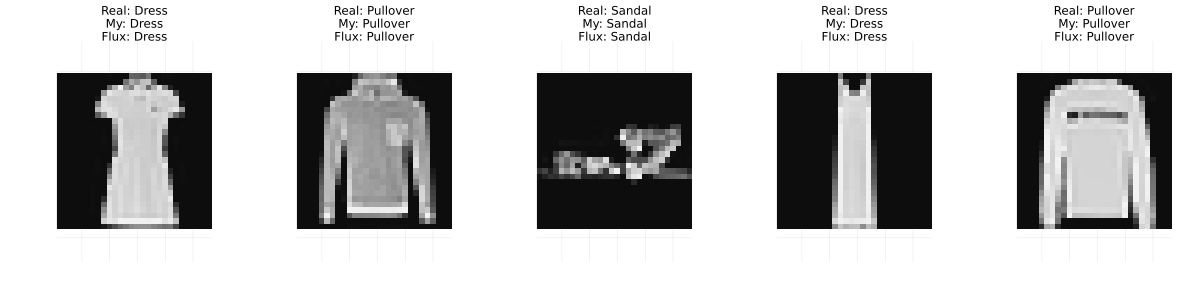

In [61]:
using Plots

# https://github.com/zalandoresearch/fashion-mnist
const LABELS = Dict(
    0 => "T-shirt/top",
    1 => "Trouser",
    2 => "Pullover",
    3 => "Dress",
    4 => "Coat",
    5 => "Sandal",
    6 => "Shirt",
    7 => "Sneaker",
    8 => "Bag",
    9 => "Ankle boot"
)

num_images  = 5
indices     = rand(1:size(X_test, 4), num_images)
final_layer = my_model.chain.layers[end]
input_node  = my_model.input

Flux.testmode!(flux_net)

plot_array = []

for idx in indices
    true_label_idx = Y_test_raw[idx]

    # ── My model inference (single sample in a batch-wide buffer) ──
    fill!(input_node.data, 0f0)
    copyto!(@view(input_node.data[:, :, :, 1:1]), @view(X_test[:, :, :, idx:idx]))
    forward!(my_model.chain, input_node, false)
    my_pred_idx = argmax(@view(final_layer.out.data[:, 1])) - 1

    # ── Flux inference ──
    flux_out      = flux_net(X_test[:, :, :, idx:idx])
    flux_pred_idx = Flux.onecold(flux_out, 0:9)[1]

    println("Obrazek $idx:")
    println("  Real:    ", LABELS[true_label_idx])
    println("  My:      ", LABELS[my_pred_idx])
    println("  Flux:    ", LABELS[flux_pred_idx])
    println("=======================")

    img_data   = X_test[:, :, 1, idx]
    title_text = "Real: $(LABELS[true_label_idx])\nMy: $(LABELS[my_pred_idx])\nFlux: $(LABELS[flux_pred_idx])"

    p = heatmap(
        img_data',
        yflip        = true,
        color        = :grays,
        legend       = false,
        aspect_ratio = :equal,
        axis         = false,
        title        = title_text,
        titlefontsize = 8
    )
    push!(plot_array, p)
end

plot(plot_array..., layout=(1, num_images), size=(1200, 300), margin=5Plots.mm)